# Análisis de Exportaciones Hortofrutícolas de Almería (2015-2024)


## Objetivo del análisis

Este notebook explora las exportaciones de productos hortofrutícolas desde Almería entre 2015 y 2024. 
Incluye limpieza de datos, análisis exploratorio y visualizaciones de:

- Exportaciones totales por año
- Top productos y países destino
- Precio medio por kilogramo


In [2]:
# Importamos pandas, la librería que nos permite trabajar con tablas (DataFrames)
import pandas as pd
import numpy as np

# Opcional: configurar pandas para mostrar más columnas y no cortar texto
pd.set_option('display.max_columns', None)  # muestra todas las columnas
pd.set_option('display.max_rows', 10)       # muestra las primeras 10 filas


In [3]:
# 2️⃣ Definimos la ruta del archivo Excel (ruta relativa)
archivo = "../Data/Raw/almeria_exportaciones_2015_2024_raw.xlsx"

# 3️⃣ Cargamos el Excel en un DataFrame
df = pd.read_excel(archivo)  # pd.read_excel abre el archivo Excel y lo convierte en tabla (DataFrame)

# 4️⃣ Mostramos las primeras 5 filas para verificar que se ha cargado correctamente
df.head()

# Revisar tipos de datos
print("Tipos de datos:")
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isnull().sum())
print("\nFilas duplicadas:")
print(df.duplicated().sum())
print("\nProductos únicos:")
print(df['product'].unique())
print("\nPaíses destino únicos:")
print(df['destination_country'].unique())

Tipos de datos:
year                     int64
product                 object
destination_country     object
value_eur              float64
weight_kg              float64
price_per_kg           float64
dtype: object

Valores nulos por columna:
year                   0
product                0
destination_country    0
value_eur              0
weight_kg              0
price_per_kg           0
dtype: int64

Filas duplicadas:
0

Productos únicos:
['PIMIENTO' 'TOMATE' 'PEPINO' 'CALABACIN' 'BERENJENA' 'JUDIA VERDE'
 'MELON' 'LECHUGA' 'SANDIA' 'BROCOLI' 'ESPINACA' 'PEPINILLO' 'ALCACHOFA'
 'COL' 'OTRAS HORTALIZAS']

Países destino únicos:
['ALEMANIA' 'FRANCIA' 'PAISES BAJOS' 'REINO UNIDO' 'BELGICA' 'POLONIA'
 'ITALIA' 'REPUBLICA CHECA' 'SUECIA' 'AUSTRIA' 'DINAMARCA' 'PORTUGAL'
 'HUNGRIA' 'RUMANIA' 'ESLOVAQUIA' 'FINLANDIA' 'SUIZA' 'NORUEGA' 'IRLANDA'
 'OTROS']


In [3]:
# --- Análisis Exploratorio Básico ---

# 1. Exportaciones por año
exportaciones_anuales = df.groupby('year')['value_eur'].sum()
print("Exportaciones por año:")
print(exportaciones_anuales)

# 2. Top 10 productos por valor
top_productos = df.groupby('product')['value_eur'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 productos por valor:")
print(top_productos)

# 3. Top 10 países destino por valor
top_paises = df.groupby('destination_country')['value_eur'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 países destino por valor:")
print(top_paises)

# 4. Precio medio por kg por producto
precio_medio = df.groupby('product')['price_per_kg'].mean().sort_values(ascending=False)
print("\nPrecio medio por kg por producto:")
print(precio_medio)


Exportaciones por año:
year
2015    2.589805e+09
2016    2.600426e+09
2017    2.863415e+09
2018    3.003222e+09
2019    3.030557e+09
2020    2.899728e+09
2021    3.140341e+09
2022    3.274500e+09
2023    3.410258e+09
2024    3.446268e+09
Name: value_eur, dtype: float64

Top 10 productos por valor:
product
PIMIENTO       7.525421e+09
TOMATE         5.293154e+09
PEPINO         4.500289e+09
CALABACIN      3.230597e+09
BERENJENA      2.459094e+09
JUDIA VERDE    1.554237e+09
MELON          1.405667e+09
LECHUGA        1.125725e+09
SANDIA         9.551620e+08
BROCOLI        8.611571e+08
Name: value_eur, dtype: float64

Top 10 países destino por valor:
destination_country
ALEMANIA           1.118299e+10
FRANCIA            4.162347e+09
PAISES BAJOS       3.312050e+09
REINO UNIDO        2.957674e+09
POLONIA            1.805294e+09
BELGICA            1.475385e+09
ITALIA             1.199308e+09
REPUBLICA CHECA    8.956342e+08
SUECIA             6.059895e+08
AUSTRIA            5.958688e+08
Name: v

## Limpieza y preparación de los datos

- Eliminamos filas duplicadas
- Verificamos valores nulos
- Estandarizamos nombres de productos y países
- Calculamos columnas adicionales si es necesario


In [4]:
# --- Limpieza de Datos Básica ---

# 1. Eliminar filas duplicadas
df = df.drop_duplicates()

# 2. Elimin1ar filas con valores nulos (si hay)
df = df.dropna()

# 3. Estandarizar strings: eliminar espacios y pasar a mayúsculas
df['product'] = df['product'].str.strip().str.upper()
df['destination_country'] = df['destination_country'].str.strip().str.upper()

# 4. Revisar tipos de datos
df['year'] = df['year'].astype(int)
df['value_eur'] = df['value_eur'].astype(float)
df['weight_kg'] = df['weight_kg'].astype(float)
df['price_per_kg'] = df['price_per_kg'].astype(float)

# Comprobación rápida
print("Datos tras limpieza:")
print(df.info())
print(df.head())


Datos tras limpieza:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 3000 non-null   int64  
 1   product              3000 non-null   object 
 2   destination_country  3000 non-null   object 
 3   value_eur            3000 non-null   float64
 4   weight_kg            3000 non-null   float64
 5   price_per_kg         3000 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 140.8+ KB
None
   year    product destination_country     value_eur     weight_kg  \
0  2015   PIMIENTO            ALEMANIA  2.104075e+08  1.276182e+08   
1  2015     TOMATE            ALEMANIA  1.863261e+08  1.260148e+08   
2  2015     PEPINO            ALEMANIA  1.485111e+08  1.458123e+08   
3  2015  CALABACIN            ALEMANIA  1.161451e+08  9.929372e+07   
4  2015   PIMIENTO             FRANCIA  8.237542e+07  

## Visualizaciones

Mostramos los resultados del análisis exploratorio mediante gráficos para identificar:

- Evolución de exportaciones por año
- Productos más exportados
- Principales países destino
- Comparativa de precios por kilogramo


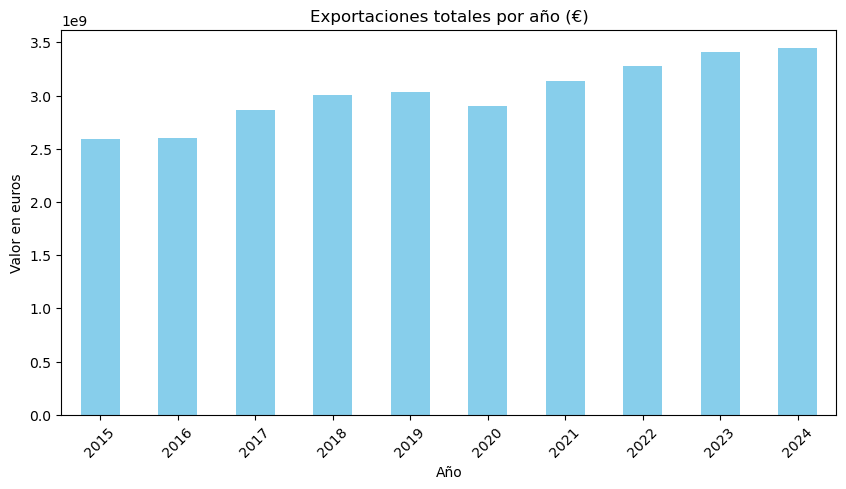

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
exportaciones_anuales.plot(kind='bar', color='skyblue')
plt.title("Exportaciones totales por año (€)")
plt.ylabel("Valor en euros")
plt.xlabel("Año")
plt.xticks(rotation=45)
plt.show()


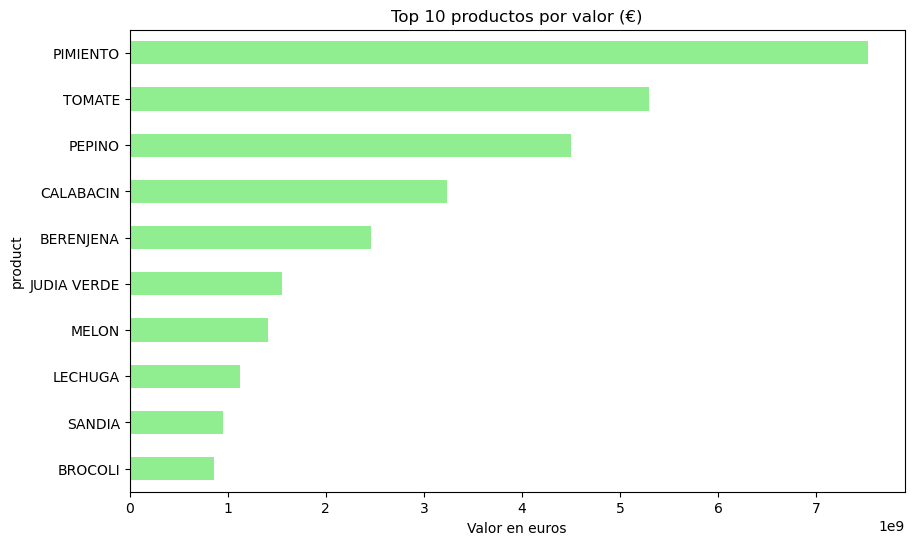

In [6]:
# Gráfico Top 10 productos por valor
plt.figure(figsize=(10,6))
top_productos.plot(kind='barh', color='lightgreen')
plt.title("Top 10 productos por valor (€)")
plt.xlabel("Valor en euros")
plt.gca().invert_yaxis()  # Para que el producto con mayor valor quede arriba
plt.show()


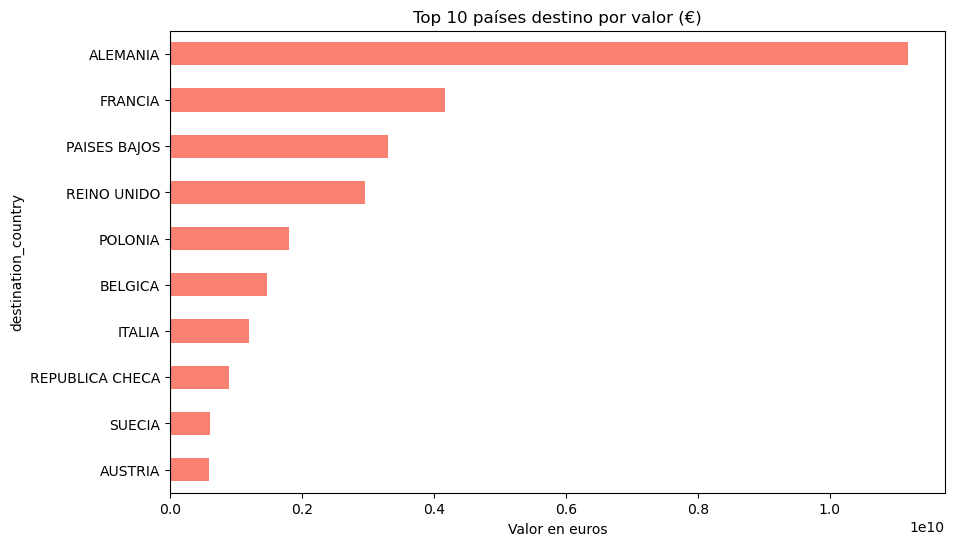

In [7]:
# Gráfico Top 10 países destino por valor
plt.figure(figsize=(10,6))
top_paises.plot(kind='barh', color='salmon')
plt.title("Top 10 países destino por valor (€)")
plt.xlabel("Valor en euros")
plt.gca().invert_yaxis()
plt.show()


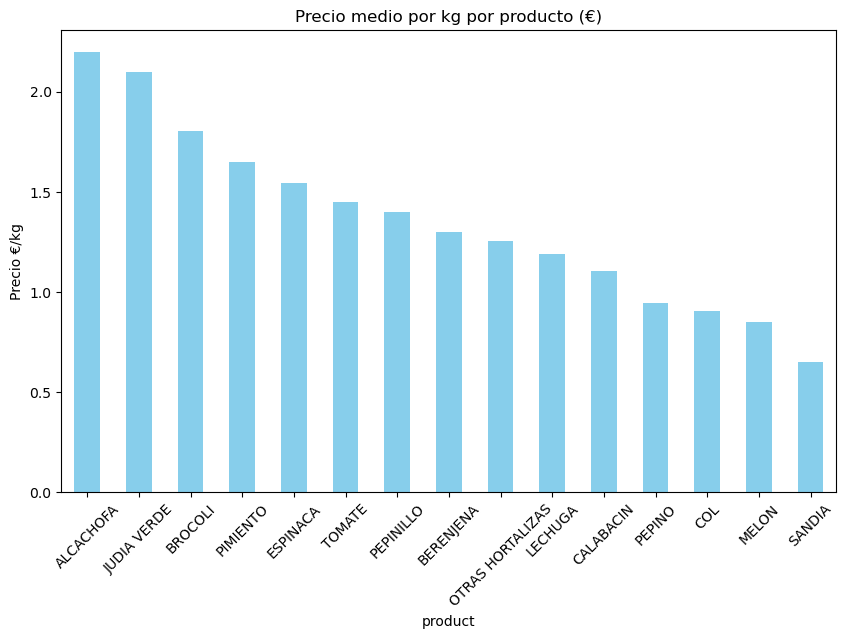

In [8]:
# Gráfico Precio medio por kg por producto
plt.figure(figsize=(10,6))
precio_medio.plot(kind='bar', color='skyblue')
plt.title("Precio medio por kg por producto (€)")
plt.ylabel("Precio €/kg")
plt.xticks(rotation=45)
plt.show()


In [9]:
# Guardar archivo limpio en CSV
df.to_csv(r"C:\Users\Esther Navarro\Desktop\portfolio almeria export\Data\Processed\almeria_exportaciones_limpio.csv", index=False)

# Guardar archivo limpio en Excel
df.to_excel(r"C:\Users\Esther Navarro\Desktop\portfolio almeria export\Data\Processed\almeria_exportaciones_limpio.xlsx", index=False)
